In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [4]:
gdf = gpd.read_file("data/processed/hazard_index_grid_final.gpkg")

In [5]:
gdf.head()

,sci_name,redlistCategory,iucn_id,vuln,mp_pieces_m3,dist_m,x,y,cell_id,index_right,...,eco_shape_richness,ecotaxa_present,FIBER,FRAGMENT,SPHERE,OTHER,hazard_pressure,hazard_morphology,hazard_index,geometry
0,Hubbsina turneri,CR,0,4,2115.655853,244627.454273,-9.791379e+06,2.486198e+06,9910,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.006732,0.731034,0.368883,POINT (-9791379.477 2486197.52)
1,Ictalurus mexicanus,VU,3,2,2820.874471,176956.192726,-9.586314e+06,2.737598e+06,10174,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.008014,0.731034,0.369524,POINT (-9586314.291 2737597.95)
2,Ameca splendens,CR,5,4,6346.967560,145126.276485,-1.004222e+07,2.609194e+06,9649,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.017544,0.731034,0.374289,POINT (-10042224.508 2609193.916)
3,Ameca splendens,CR,13,4,4231.311707,138592.329475,-9.987758e+06,2.495868e+06,9648,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.012021,0.731034,0.371528,POINT (-9987758.003 2495868.065)
4,Lucania interioris,EN,15,3,21156.558533,661939.173782,-9.851249e+06,3.313858e+06,9918,24025,...,3,1,0.62069,0.068966,0.0,0.310345,0.059315,0.731034,0.395175,POINT (-9851249.069 3313858.185)


## Objetivo ML
Predecir el impacto biológico observado (IUCN) a partir de la presión de microplásticos y su morfología, a nivel celda–especie.

## Definir el target
2 opciones:

- iucn_mean_risk
- iucn_species_count

De momento se define iucn_mean_risk como target.

In [7]:
TARGET = "iucn_mean_risk"

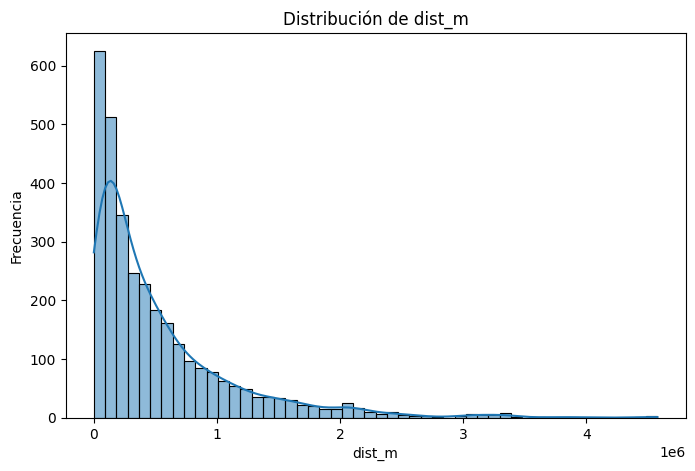

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(gdf["dist_m"].dropna(), bins=50, kde=True)
plt.xlabel("dist_m")
plt.ylabel("Frecuencia")
plt.title("Distribución de dist_m")
plt.show()

In [11]:
# Transformación de dist_m para poder ser usada evitando colas largas
gdf["log_dist_m"] = np.log1p(gdf["dist_m"])

"log_dist_m" feature clave que captura:

- exposición espacial directa
- gradiente de riesgo
- interacción con concentración

In [ ]:
# Mirar correlación para ver si se usan las dos
gdf[["dist_m", "eco_dist_m"]].corr()

,dist_m,eco_dist_m
dist_m,1.000000,-0.149968
eco_dist_m,-0.149968,1.000000


Para evaluar el papel de la presión por microplásticos en el impacto biológico observado, se compararon dos enfoques de modelado.

- El primero utiliza variables ambientales y morfológicas en su forma original, permitiendo al modelo aprender relaciones no lineales directamente a partir de los datos.
- El segundo emplea un índice de riesgo experto que sintetiza la presión por microplásticos, con el objetivo de evaluar si dicha agregación previa captura de forma suficiente la señal relevante para explicar el riesgo biológico.
Ambos modelos incorporan métricas de proximidad espacial a microplásticos, con el fin de representar la exposición directa de las especies.

### Modelo 1 — RAW (sin índice experto)

In [ ]:
FEATURES_RAW = [
    # presión microplásticos
    "noaa_mp_mean",
    "noaa_mp_max",
    "noaa_mp_count",
    "mp_pieces_m3",

    # morfología (proporciones)
    "FIBER",
    "FRAGMENT",
    "SPHERE",
    "OTHER",
    "eco_shape_richness",

    # proximidad a microplásticos
    "log_dist_m",
    "eco_dist_m",

    # contexto ecológico
    "eco_count",
    "eco_mean_size",
    "eco_small_ratio",
]

### Modelo 2 - Índice

In [18]:
FEATURES_INDEX = [
    # índice sintético
    "hazard_index",

    # proximidad a microplásticos
    "log_dist_m",
    "eco_dist_m",

    # contexto ecológico
    "eco_count",
    "eco_mean_size",
    "eco_small_ratio",
]

In [15]:
# limpiar dataset
df = gdf.dropna(subset=[TARGET]).copy()

groups = df["cell_id"]

groups asegura que el modelo se evalúe en nuevas celdas espaciales, evitando fuga de información entre entrenamiento y test.

In [20]:
def evaluate_model(X, y, groups, model, cv):
    scores = []

    for train_idx, test_idx in cv.split(X, y, groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        scores.append({
            "r2": r2_score(y_test, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred))
        })

    return pd.DataFrame(scores)

In [21]:
cv = GroupKFold(n_splits=5)

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

In [22]:
# RAW
X_raw = df[FEATURES_RAW]
y = df[TARGET]

scores_raw = evaluate_model(X_raw, y, groups, rf, cv)
scores_raw["model"] = "RAW"

# INDEX
X_index = df[FEATURES_INDEX]

scores_index = evaluate_model(X_index, y, groups, rf, cv)
scores_index["model"] = "INDEX"


In [23]:
results = pd.concat([scores_raw, scores_index])
results.groupby("model").agg(["mean", "std"])

r2                rmse          
           mean       std      mean       std
model                                        
INDEX  0.305441  0.020800  0.640382  0.009426
RAW    0.359539  0.022415  0.614944  0.012327

In [24]:
rf.fit(X_raw, y)
importances_raw = pd.Series(
    rf.feature_importances_,
    index=FEATURES_RAW
).sort_values(ascending=False)

In [25]:
importances_raw

eco_dist_m            0.349338
log_dist_m            0.215172
eco_count             0.072450
noaa_mp_max           0.067890
noaa_mp_mean          0.065358
mp_pieces_m3          0.060673
noaa_mp_count         0.048231
OTHER                 0.031863
eco_mean_size         0.028752
eco_small_ratio       0.023592
FRAGMENT              0.015334
FIBER                 0.015120
SPHERE                0.004760
eco_shape_richness    0.001466
dtype: float64